# Analysis of a Mobile App Selling Grocery Products.
# A/B Testing

We need to understand how mobile app users behave.
We will study the sales funnel, find out how users reach the point of purchase. We will answer to the questions of how many users make it to the purchase, and how many get stuck at previous steps? Which ones?
Then, we need to examine the results of an A/B experiment. The designers wanted to change the fonts throughout the app, but the managers are worried that users would feel unfamiliar. They agreed to base their decision on the results of an A/B test. For this test, users were divided into three groups: two control groups with the old fonts and one experimental group with the new ones. We need to determine which font is better.

* [Step 1. General Information](#1-bullet)
* [Step 2. Data Preprocessing](#2-bullet)
* [Step 3. Data Examination and Validation](#3-bullet)
* [Step 4. Funnel Analysis](#4-bullet)
* [Step 5. Experiment Results Analysis](#5-bullet)
* [Step 6. Conclusion](#6-bullet)

## Step 1. General Information<a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import copy

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/logs_exp.csv', sep='\t', decimal=',')

In [3]:
df.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


**Data Description:**

    EventName — Event Name;
    DeviceIDHash — Unique User Identifier;
    EventTimestamp — Event Time;
    ExpId — Experiment Number: 246 and 247 are the Control Groups, and 248 is the Experimental Group.

### Step 2. Data Preprocessing<a class="anchor" id="2-bullet"></a>

**Let's replace the column names with more convenient ones**

In [4]:
df.rename(columns={'EventName': 'event', 'DeviceIDHash': 'user_id', 'EventTimestamp': 'event_time', 'ExpId':'group'}, inplace=True)
df.head()

,event,user_id,event_time,group
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   event       244126 non-null  object
 1   user_id     244126 non-null  int64 
 2   event_time  244126 non-null  int64 
 3   group       244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


    Table 244 contains 126 rows, with no missing values. Data types are correct.

**Let's add a date and time column, as well as a separate date column**

In [6]:
df.event_time = pd.to_datetime(df.event_time, unit = 's')
df['date'] = df.event_time.dt.date
df.head()

,event,user_id,event_time,group,date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


**Search for duplicates**

In [7]:
df[df.duplicated(keep=False) == True]

,event,user_id,event_time,group,date
452,MainScreenAppear,5613408041324010552,2019-07-30 08:19:44,248,2019-07-30
453,MainScreenAppear,5613408041324010552,2019-07-30 08:19:44,248,2019-07-30
2348,CartScreenAppear,1694940645335807244,2019-07-31 21:51:39,248,2019-07-31
2350,CartScreenAppear,1694940645335807244,2019-07-31 21:51:39,248,2019-07-31
3572,MainScreenAppear,434103746454591587,2019-08-01 02:59:37,248,2019-08-01
...,...,...,...,...,...
242359,PaymentScreenSuccessful,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07
242360,PaymentScreenSuccessful,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07
242362,CartScreenAppear,2382591782303281935,2019-08-07 19:27:29,246,2019-08-07
242634,MainScreenAppear,4097782667445790512,2019-08-07 19:36:58,246,2019-08-07


In [8]:
df.duplicated().sum()

413

In [9]:
df = df.drop_duplicates()

    There were 413 duplicate stocks in the table that were removed.

## Step 3. Data Examination and Validation<a class="anchor" id="3-bullet"></a>

**How ​​many events are there in the log?**

In [10]:
events = len(df)
print('Total events in the log: {}'.format(events), 'pc.')

Total events in the log: 243713 pc.


**How ​​many users are there in the log?**

In [11]:
users = df['user_id'].nunique()
print('Total unique users in the log: {}'.format(users))

Total unique users in the log: 7551


**How ​​many events per user on average?**

    To determine the average number of events per user, 
    we'll find measures of central tendency: mean, median, and mode.

In [12]:
mean = df.groupby('user_id')['event'].count().mean().round()
print('On average, there are events per user: {}'.format(mean))

On average, there are events per user: 32.0


In [13]:
median = df.groupby('user_id')['event'].count().median().round()
print('On average, there are events per user: {}'.format(median))

On average, there are events per user: 20.0


In [14]:
mode = df.groupby('user_id')['event'].count().mode()
print('On average, there are events per user: {}'.format(mode))

On average, there are events per user: 0    5
dtype: int64


**For what period do we have data?**

In [15]:
df['date'].min()

datetime.date(2019, 7, 25)

In [16]:
df['date'].max()

datetime.date(2019, 8, 7)

    Time frame: period starts on 2019-07-25, period ends on 2019-08-07

In [17]:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

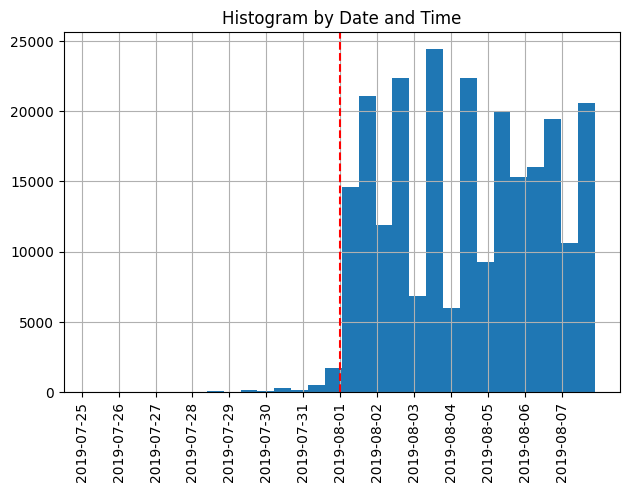

In [18]:
# Calculating dates for the X-axis
start = df.date.min()
end = df.date.max()
dates = pd.date_range(start, end, freq='D')

df['event_time'].hist(grid=True, bins=30, xrot=90)
plt.xticks(dates)
plt.tight_layout()
plt.title('Histogram by Date and Time')

# A vertical line to separate the trial period
plt.axvline(pd.to_datetime('2019-08-01'), ls='--', color='r')
plt.show()

    We don't have enough data for the period from 2019-07-25 to 2019-07-31.
    Data from 2019-08-01 to 2019-08-07 is complete.

In [19]:
# Leave full data
date_threshold = pd.to_datetime('2019-08-01', format = '%Y-%m-%d')
df_cor_date = df[df['date'] >= date_threshold]

In [20]:
df_cor_date['date'].unique()

array([datetime.date(2019, 8, 1), datetime.date(2019, 8, 2),
       datetime.date(2019, 8, 3), datetime.date(2019, 8, 4),
       datetime.date(2019, 8, 5), datetime.date(2019, 8, 6),
       datetime.date(2019, 8, 7)], dtype=object)

**How ​​many events and users did we lose by discarding old data?**

In [21]:
filtered_events = len(df_cor_date)
difference = len(df) - len(df_cor_date)
difference2 = difference*100/len(df)
print('Total events in the filtered table: {}'.format(filtered_events), 'pc.')
print('Total events in the original table: {}'.format(events), 'pc.')
print('Difference between events: {}'.format(difference), 'pc. or {:.2f}%'.format(difference2))

Total events in the filtered table: 240887 pc.
Total events in the original table: 243713 pc.
Difference between events: 2826 pc. or 1.16%


In [22]:
filtered_users = df_cor_date['user_id'].nunique()
difference_users = df['user_id'].nunique() - df_cor_date['user_id'].nunique()
difference_users2 = difference_users*100/df['user_id'].nunique()
print('Total unique users in the original table: {}'.format(users), 'people')
print('Total unique users in the filtered table: {}'.format(filtered_users), 'people')
print('Difference between users: {}'.format(difference_users), 'or {:.2f}%'.format(difference_users2))

Total unique users in the original table: 7551 people
Total unique users in the filtered table: 7534 people
Difference between users: 17 or 0.23%


**Make sure you have users from all three experimental groups**

In [23]:
df_cor_date['group'].value_counts()

248    84563
246    79302
247    77022
Name: group, dtype: int64

## Step 4. Funnel Analysis<a class="anchor" id="4-bullet"></a>

**Let's look at the events in the logs and how often they occur and sort the events by frequency**

In [24]:
events_count = df_cor_date.groupby('event').agg({'user_id':'count'}).reset_index().sort_values(by='user_id', ascending=False)
events_count.rename(columns={'event': 'name_event', 'user_id': 'quantity_events'}, inplace=True)
events_count

,name_event,quantity_events
1,MainScreenAppear,117328
2,OffersScreenAppear,46333
0,CartScreenAppear,42303
3,PaymentScreenSuccessful,33918
4,Tutorial,1005


A total of 5 events, sorted by frequency:

* MainScreenAppear - main screen appearance
* OffersScreenAppear - product offer (product screen)
* CartScreenAppear - transition to cart
* PaymentScreenSuccessful - successful payment screen
* Tutorial - optional tutorial on how to use the app

**Count how many users performed each of these events, sort the events by number of users, calculate the proportion of users who performed the event at least once**

In [25]:
quantity_unique_users = df_cor_date.groupby('event').agg({'user_id':'nunique'}).reset_index().sort_values(by='user_id', ascending=False)
quantity_unique_users.rename(columns={'event': 'name_event', 'user_id': 'quantity_unique_users'}, inplace=True)
quantity_unique_users

,name_event,quantity_unique_users
1,MainScreenAppear,7419
2,OffersScreenAppear,4593
0,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


    We've got a funnel of events. Let's plot a graph.

Text(0.5, 0, 'Number of Unique Users Who Performed the Event')

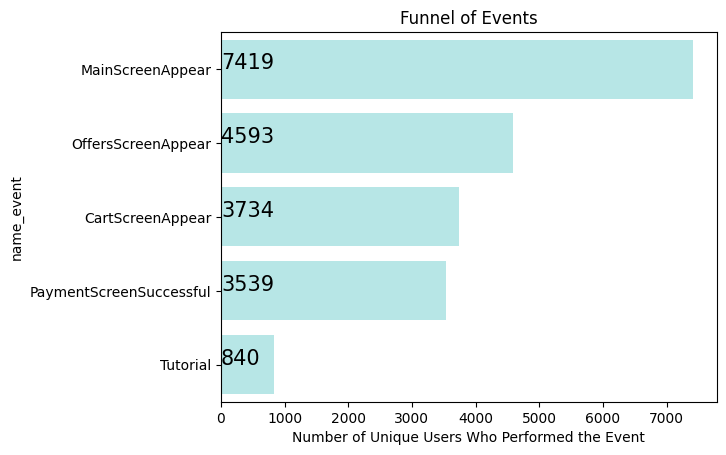

In [26]:
fig = ax = sns.barplot(x='quantity_unique_users', y='name_event', data=quantity_unique_users, color='paleturquoise')
plt.text(1, 0, "7419", fontsize=15)
plt.text(1, 1, "4593", fontsize=15)
plt.text(1, 2, "3734", fontsize=15)
plt.text(1, 3, "3539", fontsize=15)
plt.text(1, 4, "840", fontsize=15)
plt.title('Funnel of Events')
ax.set_xlabel('Number of Unique Users Who Performed the Event')

In [27]:
from plotly import graph_objects as go
fig = go.Figure(go.Funnel(
    y = ["MainScreenAppear","OffersScreenAppear", "CartScreenAppear", "PaymentScreenSuccessful"],
    x = [7419, 4593,  3734, 3539]
    ))
fig.show()

    Let's join the two tables to get the event name, the number of events, 
    and the number of events completed by unique users.

In [28]:
event_table = pd.concat([events_count, quantity_unique_users['quantity_unique_users']],axis=1)
event_table

,name_event,quantity_events,quantity_unique_users
1,MainScreenAppear,117328,7419
2,OffersScreenAppear,46333,4593
0,CartScreenAppear,42303,3734
3,PaymentScreenSuccessful,33918,3539
4,Tutorial,1005,840


    Let's find the total number of unique users in the dataset to determine the proportion
    of users who have performed a given event at least once.

In [29]:
df_cor_date['user_id'].nunique()

7534

In [30]:
event_table['percent'] = event_table['quantity_unique_users'].apply(lambda x: round(x/7534*100, 1))
event_table

,name_event,quantity_events,quantity_unique_users,percent
1,MainScreenAppear,117328,7419,98.5
2,OffersScreenAppear,46333,4593,61.0
0,CartScreenAppear,42303,3734,49.6
3,PaymentScreenSuccessful,33918,3539,47.0
4,Tutorial,1005,840,11.1


**Guessing the order in which events occur. Do they all form a sequential chain?**

Let's assume that most users follow this path:
* visit the homepage
* visit a product offer page
* add an item to the cart
* pay for the order

In [31]:
df_cor_date_main_event = df_cor_date[df_cor_date['event'] != 'Tutorial']

In [32]:
users = df_cor_date_main_event.pivot_table(
        index='user_id', 
        columns='event', 
        values='event_time',
        aggfunc='min')
users.head()

event,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful
user_id,,,,
6888746892508752,NaT,2019-08-06 14:06:34,NaT,NaT
6909561520679493,2019-08-06 18:52:58,2019-08-06 18:52:54,2019-08-06 18:53:04,2019-08-06 18:52:58
6922444491712477,2019-08-04 14:19:40,2019-08-04 14:19:33,2019-08-04 14:19:46,2019-08-04 14:19:40
7435777799948366,NaT,2019-08-05 08:06:34,NaT,NaT
7702139951469979,2019-08-02 14:28:45,2019-08-01 04:29:54,2019-08-01 04:29:56,2019-08-02 14:28:45


    Each table row is a user.
    The columns contain the first trigger time of each event.
    If an event has not occurred, its cell contains NaN.

In [33]:
step_1 = ~users['MainScreenAppear'].isna()
step_2 = step_1 & (users['OffersScreenAppear'] > users['MainScreenAppear'])
step_3 = step_2 & (users['CartScreenAppear'] > users['OffersScreenAppear'])
step_4 = step_3 & (users['PaymentScreenSuccessful'] > users['OffersScreenAppear'])

In [34]:
n_main_pageview = users[step_1].shape[0]
n_offer_pageview = users[step_2].shape[0]
n_add_to_cart = users[step_3].shape[0]
n_payment = users[step_4].shape[0]

In [35]:
print('Users visited the main page:', n_main_pageview)
print('Users visited the product offer page:', n_offer_pageview)
print('Users added product to cart:', n_add_to_cart)
print('Users paid:', n_payment)

Users visited the main page: 7419
Users visited the product offer page: 4201
Users added product to cart: 1767
Users paid: 1665


    Compare the resulting funnel, taking into account the order of user actions, with a simple funnel.
    It looked like this:

In [36]:
quantity_unique_users

,name_event,quantity_unique_users
1,MainScreenAppear,7419
2,OffersScreenAppear,4593
0,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


The number of users at the first two steps is consistent, but then diverges. This means that not all users follow the expected path.

* The MainScreenAppear step is the first step for 98.5% of unique users.
* The OffersScreenAppear step is the second step for 91.47% of unique users.
* The CartScreenAppear step is the third step for 47.32% of unique users.
* The PaymentScreenSuccessful step is the fourth step for 47.05% of unique users.

**Using an event funnel, we calculate what proportion of users progress to the next step of the funnel (relative to the number of users in the previous step). That is, for the sequence of events A → B → C, we calculate the ratio of the number of users with event B to the number of users with event A.**

In [37]:
funnel_of_events = df_cor_date.groupby('event').agg({'user_id':'nunique'}).reset_index()
funnel_of_events.sort_values(by = 'user_id', ascending=False)

,event,user_id
1,MainScreenAppear,7419
2,OffersScreenAppear,4593
0,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


In [38]:
conversion_step2 = round(4593/7419*100)
conversion_step3 = round(3734/4593*100)
conversion_step4 = round(3539/3734*100)

print('% of users moved to the second stage: {}'.format(conversion_step2))
print('% of users moved to the third stage: {}'.format(conversion_step3))
print('% of users moved to the fourth stage: {}'.format(conversion_step4))

% of users moved to the second stage: 62
% of users moved to the third stage: 81
% of users moved to the fourth stage: 95


    The largest number of lost users occurs during the second stage.
    After landing on the homepage,
    only 62% of users proceed to the product offer page.
    47.7% of users proceed from the first step to payment.

## Step 5. Experiment Results Analysis<a class="anchor" id="5-bullet"></a>

**How ​​many users are in each experimental group?**

In [39]:
users_per_group = df_cor_date.groupby('group')['user_id'].nunique().to_frame()
users_per_group.rename(columns={'user_id': 'users_count'}, inplace=True)
users_per_group.loc['246_247'] = 4997
users_per_group

,users_count
group,
246,2484
247,2513
248,2537
246_247,4997


**There are two control groups for the A/A experiment to verify the validity of all mechanisms and calculations. Check whether the statistical tests find a difference between samples 246 and 247**

1. Select the most popular event.
2. Calculate the number of users who completed this event in each control group.
3. Calculate the proportion of users who completed this event.
4. Check whether the difference between the groups is statistically significant.
5. Repeat for all other events.

    Let's create a table that will calculate the number of users who performed each event for all groups.

In [40]:
groups = df_cor_date.pivot_table(values='user_id', index='group', columns='event', aggfunc='nunique')
groups

event,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
group,,,,,
246,1266,2450,1542,1200,278
247,1238,2476,1520,1158,283
248,1230,2493,1531,1181,279


    Let's add a number of users to each group

In [41]:
groups = pd.concat([groups, users_per_group['users_count']],axis=1)
groups

,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial,users_count
group,,,,,,
246,1266.0,2450.0,1542.0,1200.0,278.0,2484
247,1238.0,2476.0,1520.0,1158.0,283.0,2513
248,1230.0,2493.0,1531.0,1181.0,279.0,2537
246_247,NaN,NaN,NaN,NaN,NaN,4997


    Let's create a new row in which we'll calculate the results 
    for the combined control group (group 246 and group 247).

In [42]:
new_row = groups.loc[246] + groups.loc[247]
new_row.name = '246_247'
groups = groups.append([new_row])
groups

,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial,users_count
246,1266.0,2450.0,1542.0,1200.0,278.0,2484.0
247,1238.0,2476.0,1520.0,1158.0,283.0,2513.0
248,1230.0,2493.0,1531.0,1181.0,279.0,2537.0
246_247,NaN,NaN,NaN,NaN,NaN,4997.0
246_247,2504.0,4926.0,3062.0,2358.0,561.0,4997.0


In [43]:
groups = groups[['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful', 'Tutorial', 'users_count']]
groups

,MainScreenAppear,OffersScreenAppear,CartScreenAppear,PaymentScreenSuccessful,Tutorial,users_count
246,2450.0,1542.0,1266.0,1200.0,278.0,2484.0
247,2476.0,1520.0,1238.0,1158.0,283.0,2513.0
248,2493.0,1531.0,1230.0,1181.0,279.0,2537.0
246_247,NaN,NaN,NaN,NaN,NaN,4997.0
246_247,4926.0,3062.0,2504.0,2358.0,561.0,4997.0


**We calculate the proportion of users who performed each event in all groups.**

In [44]:
groups1 = copy.deepcopy(groups)
groups1['percent_MainScreen'] = round(groups1['MainScreenAppear']/groups1['users_count']*100, 2)
groups1['percent_Offers'] = round(groups1['OffersScreenAppear']/groups1['users_count']*100, 2)
groups1['percent_Cart'] = round(groups1['CartScreenAppear']/groups1['users_count']*100, 2)
groups1['percent_Payment'] = round(groups1['PaymentScreenSuccessful']/groups1['users_count']*100, 2)
groups1['percent_Tutorial'] = round(groups1['Tutorial']/groups1['users_count']*100, 2)
groups1

,MainScreenAppear,OffersScreenAppear,CartScreenAppear,PaymentScreenSuccessful,Tutorial,users_count,percent_MainScreen,percent_Offers,percent_Cart,percent_Payment,percent_Tutorial
246,2450.0,1542.0,1266.0,1200.0,278.0,2484.0,98.63,62.08,50.97,48.31,11.19
247,2476.0,1520.0,1238.0,1158.0,283.0,2513.0,98.53,60.49,49.26,46.08,11.26
248,2493.0,1531.0,1230.0,1181.0,279.0,2537.0,98.27,60.35,48.48,46.55,11.00
246_247,NaN,NaN,NaN,NaN,NaN,4997.0,NaN,NaN,NaN,NaN,NaN
246_247,4926.0,3062.0,2504.0,2358.0,561.0,4997.0,98.58,61.28,50.11,47.19,11.23


**Difference in the Share of Users Who Completed the Most Popular Events:**

**MainScreenAppear:**
* 246 - (control group) maximum rate of 98.63%
* 247 - (control group), third rate, 0.1% lower than the maximum.
* 248 - (experimental group), fourth rate, 0.36% lower than the maximum.
* 246_247 - second rate, 0.05% lower than the maximum.

**Let's check whether the difference between the groups is statistically significant**

***Null Hypothesis*** - There is no statistically significant difference between the sample groups (pairs: 246 and 247, 246 and 248, 247 and 248, combined group and 248).

***Alternative Hypothesis*** - There is a statistically significant difference between the sample groups (pairs: 246 and 247, 246 and 248, 247 and 248, combined group and 248).

We will compare the proportions of two populations based on their samples using the z-test.

In [45]:
users_events_per_group = df_cor_date.pivot_table(values='user_id', index='event', columns='group', aggfunc='nunique')
users_events_per_group['246_247'] = users_events_per_group[246] + users_events_per_group[247]
users_events_per_group

group,246,247,248,246_247
event,,,,
CartScreenAppear,1266,1238,1230,2504
MainScreenAppear,2450,2476,2493,4926
OffersScreenAppear,1542,1520,1531,3062
PaymentScreenSuccessful,1200,1158,1181,2358
Tutorial,278,283,279,561


In [46]:
from scipy import stats as st
import numpy as np
import math as mth
from termcolor import colored

In [47]:
# Let's Use Z Test
def z_test(group1, group2, event, alpha): 
    p1_ev = users_events_per_group.loc[event, group1]
    p2_ev = users_events_per_group.loc[event, group2] 
    p1_us = users_per_group.loc[group1, 'users_count'] 
    p2_us = users_per_group.loc[group2, 'users_count'] 
    p1 = p1_ev / p1_us 
    p2 = p2_ev / p2_us 
    difference = p1 - p2
    p_combined = (p1_ev + p2_ev) / (p1_us + p2_us) 
    z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1 / p1_us + 1 / p2_us))
    distr = st.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    print('Check for  {} и {}, event: {}, p-value: {p_value:.2f}'.format(group1, group2, event, p_value=p_value))
    if (p_value < alpha):
        print(colored('We reject the null hypothesis: there is a significant difference between the proportions', 'green'))
    else:
        print(colored('The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.', 'red'))

***Events in control groups 246 and 247***

In [48]:
for event in users_events_per_group.index:
    z_test(246, 247, event, 0.05)
    print()

Check for  246 и 247, event: CartScreenAppear, p-value: 0.23
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 247, event: MainScreenAppear, p-value: 0.76
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 247, event: OffersScreenAppear, p-value: 0.25
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 247, event: PaymentScreenSuccessful, p-value: 0.11
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 247, event: Tutorial, p-value: 0.94
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.



***Events in the control group 246 and the experimental group 248***

In [49]:
for event in users_events_per_group.index:
    z_test(246, 248, event, 0.05)
    print()

Check for  246 и 248, event: CartScreenAppear, p-value: 0.08
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 248, event: MainScreenAppear, p-value: 0.29
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 248, event: OffersScreenAppear, p-value: 0.21
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 248, event: PaymentScreenSuccessful, p-value: 0.21
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246 и 248, event: Tutorial, p-value: 0.83
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.



***Events in the control group 247 and the experimental group 248***

In [50]:
for event in users_events_per_group.index:
    z_test(247, 248, event, 0.05)
    print()

Check for  247 и 248, event: CartScreenAppear, p-value: 0.58
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  247 и 248, event: MainScreenAppear, p-value: 0.46
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  247 и 248, event: OffersScreenAppear, p-value: 0.92
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  247 и 248, event: PaymentScreenSuccessful, p-value: 0.74
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  247 и 248, event: Tutorial, p-value: 0.77
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.



***Events in the combined control group (246 + 247) and experimental 248***

In [51]:
for event in users_events_per_group.index:
    z_test('246_247', 248, event, 0.05)
    print()

Check for  246_247 и 248, event: CartScreenAppear, p-value: 0.18
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246_247 и 248, event: MainScreenAppear, p-value: 0.29
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246_247 и 248, event: OffersScreenAppear, p-value: 0.43
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246_247 и 248, event: PaymentScreenSuccessful, p-value: 0.60
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.

Check for  246_247 и 248, event: Tutorial, p-value: 0.76
The null hypothesis could not be rejected; there is no reason to believe that the proportions are different.



### Step 6. Conclusion<a class="anchor" id="6-bullet"></a>

No statistically significant differences were found between the two control groups, 246 and 247. This is one of the criteria for the success of an A/A test.

No statistically significant differences were found between the control groups and the experimental group, meaning that the hypothesis that changing the font on the homepage would impact conversion metrics was not confirmed.

It's important to note that the experiment was conducted for one week. This may not be enough to detect differences. It's recommended to estimate the minimum test duration using an A/B test duration calculator and continue the test if necessary.

When changing the significance level to 0.1 (alpha = 0.1), statistical differences were found in only one experiment: ***CartScreenAppear event (control group 246 and experimental group 248)***

When choosing the critical significance level, consider the sample size. With a small sample size, it's more likely to obtain a random result, for example, a difference between two homogeneous samples. Therefore, a higher probability of Type I error can be assumed. As the sample size increases, random variations cancel each other out, and a significant difference between homogeneous samples is less likely. If the sample size is small, up to 100 units, then the null hypothesis can be rejected with a significance level of 0.1. For sample sizes in the hundreds—from 100 to 1000—the significance level should be lowered to at least 0.05.

Based on the above, the previous significance level of alpha = 0.05 was retained.

**Sales Funnel**
* MainScreenAppear - 7,419 users
* OffersScreenAppear - 4,593 users
* CartScreenAppear - 734 users
* PaymentScreenSuccessful - 3,539 users
* Tutorial - 840 users

**Order of Events**
* Stage 1 MainScreenAppear - occurs first for 98.5% of unique users.
* Stage 2 OffersScreenAppear - occurs second for 91.47% of unique users.
* Stage 3 CartScreenAppear - occurs third for 47.32% of unique users.
* Stage 4 PaymentScreenSuccessful - occurs fourth for 47.05% of unique users.

**Share of users who proceeded to the next step**
* % of users who proceeded to the second step: 62%
* % of users who proceeded to the third step: 81%
* % of users who proceeded to the fourth step: 95%

The second step is where the largest number of users are lost. After landing on the homepage, only 62% of users proceed to the product offer page. 47.7% of users complete the first step and proceed to payment.